In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
np.random.seed(42)

data = {
    "CustomerID": range(1, 201),
    "Age": np.random.randint(18, 60, 200),
    "Annual_Income": np.random.randint(20000, 120000, 200),
    "Spending_Score": np.random.randint(1, 100, 200),
    "Total_Purchases": np.random.randint(1, 50, 200),
    "Monthly_Sales": np.random.randint(500, 10000, 200)
}

df = pd.DataFrame(data)
df.head()

,CustomerID,Age,Annual_Income,Spending_Score,Total_Purchases,Monthly_Sales
0,1,56,45342,70,43,5030
1,2,46,57157,15,11,7381
2,3,32,87863,54,18,7449
3,4,25,72083,60,47,6741
4,5,38,85733,97,12,8517


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       200 non-null    int64
 1   Age              200 non-null    int32
 2   Annual_Income    200 non-null    int32
 3   Spending_Score   200 non-null    int32
 4   Total_Purchases  200 non-null    int32
 5   Monthly_Sales    200 non-null    int32
dtypes: int32(5), int64(1)
memory usage: 5.6 KB


,CustomerID,Age,Annual_Income,Spending_Score,Total_Purchases,Monthly_Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.665000,67700.155000,50.460000,24.320000,5305.590000
std,57.879185,12.604648,29207.658499,30.047674,14.549779,2669.531004
min,1.000000,18.000000,20301.000000,1.000000,1.000000,505.000000
25%,50.750000,27.750000,42278.750000,23.000000,11.750000,3031.250000
50%,100.500000,40.000000,67293.500000,52.000000,25.000000,5625.000000
75%,150.250000,49.250000,92235.000000,76.000000,37.000000,7441.000000
max,200.000000,59.000000,119713.000000,99.000000,49.000000,9944.000000


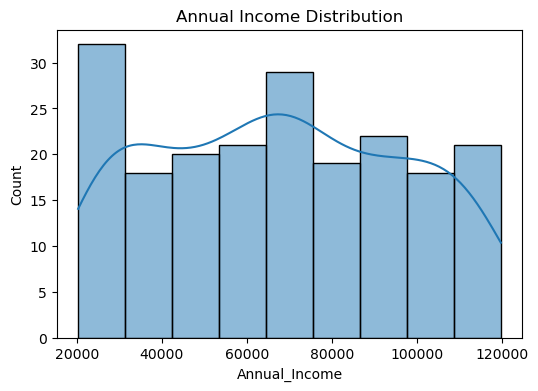

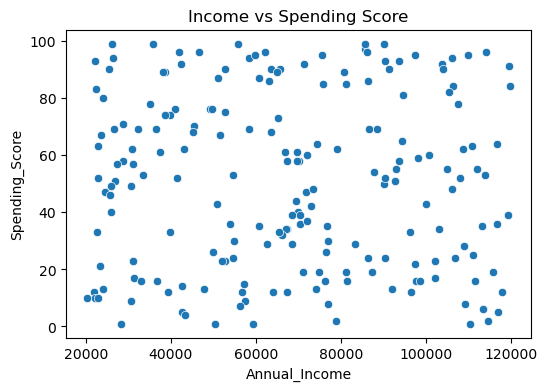

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual_Income"], kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Annual_Income", y="Spending_Score", data=df)
plt.title("Income vs Spending Score")
plt.show()

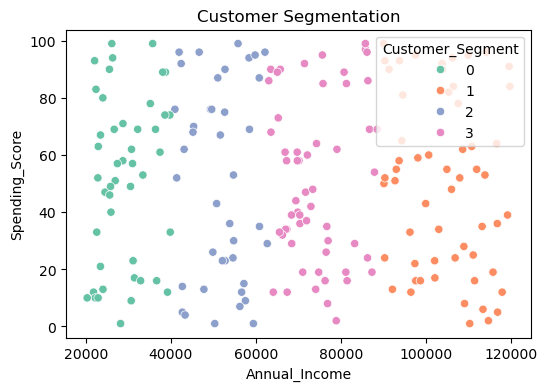

In [9]:
X = df[["Annual_Income", "Spending_Score"]]

kmeans = KMeans(n_clusters=4, random_state=42)
df["Customer_Segment"] = kmeans.fit_predict(X)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Customer_Segment",
    data=df,
    palette="Set2"
)
plt.title("Customer Segmentation")
plt.show()

In [11]:
X = df[["Age", "Annual_Income", "Spending_Score", "Total_Purchases"]]
y = df["Monthly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

2812.727403152066

In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

coefficients

,Feature,Impact
0,Age,10.034871
1,Annual_Income,-0.002627
2,Spending_Score,5.622842
3,Total_Purchases,-39.644643
